## Question 1 and Multilevel Monte Carlo 
In this notebook we answer question 1 from the Simulation assignment and reperform and extend Giles 2008 numerical experiments.  

Methodology
In section 1 we solve question 1
In section 2-3 we replicate Giles 2008 MLMC methodology on European Call options under a GBM and Heston volatility model
In section 4 we extend the MLMC approach to a basket of 5 correlated Asian Options following the Milstein Scheme and using Brownian Interpolation
In section 5-6 we expand our experiment to the MLQMC adding randomised rank-1 lattice + Brownian bridge to the multilevel framework




##### Import Libraries

In [1]:
from typing import Callable, Dict, List, Optional, Sequence, Tuple
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm

### Section 1 - Question 1

### Section 2 - Multilevel Monte Carlo reproduction - European Call with GBM/ Heston - Setup

##### a) Create class to store and update variances of correction terms, fine estimator, variance of richardson extention per level

In [2]:

#Store variance of correction terms, variance of fine estimator, variance of Richardson extension per level, and update each time algorithm re run  
class LevelData:
    def __init__(self,
                 n: int = 0,
                 sum_y: float = 0.0,
                 sum_y2: float = 0.0,
                 sum_pf: float = 0.0,
                 sum_pf2: float = 0.0,
                 sum_pext: float = 0.0,
                 sum_pext2: float = 0.0,
                 cost: float = 0.0):
        self.n = n
        self.sum_y = sum_y
        self.sum_y2 = sum_y2
        self.sum_pf = sum_pf
        self.sum_pf2 = sum_pf2
        self.sum_pext = sum_pext
        self.sum_pext2 = sum_pext2 
        self.cost = cost

    def update(self, y: np.ndarray, pf: np.ndarray, pext: np.ndarray, cost_per_sample: float) -> None:
        y = np.asarray(y, dtype=float)
        pf = np.asarray(pf, dtype=float)
        m = len(y)
        self.n += m
        self.sum_y += float(np.sum(y))
        self.sum_y2 += float(np.sum(y * y))
        self.sum_pf += float(np.sum(pf))
        self.sum_pf2 += float(np.sum(pf * pf))
        self.sum_pext += float(np.sum(pext))
        self.sum_pext2 += float(np.sum(pext * pext))
        self.cost += float(m * cost_per_sample)
    def mean(self) -> float:
        return self.sum_y / max(self.n, 1)

    #variance of correction terms
    def var(self) -> float:
        if self.n <= 1:
            return 0.0
        mean = self.mean()
        return max(self.sum_y2 / self.n - mean * mean, 0.0)

    #Variance of estimated payoff - used for regular MC 
    def fine_var(self) -> float:
        if self.n <= 1:
            return 0.0
        mean_pf = self.sum_pf / self.n
        return max(self.sum_pf2 / self.n - mean_pf * mean_pf, 0.0)
    
    #Variance of estimated payoff using richardson - used for regular MC 
    def fine_var_ext(self) -> float:
        if self.n <= 1:
            return 0.0
        mean = self.sum_pext / self.n
        return max(self.sum_pext2 / self.n - mean * mean, 0.0)
    
    def cost_per_sample(self) -> float:
        return self.cost / max(self.n, 1)

#Store the result of each Mlmc run. Stored in a class rather than an array to keep track of each item of data
#ext = Extension using Richardson estimator and stop rule (11)
class MlmcResult:
    def __init__(self,
                eps: float,
                L: int,
                estimate: float,
                estimate_ext: float,
                levels: List[LevelData],
                target_N: np.ndarray,
                history: List[Dict[str, object]],
                converged: bool,
                bias_proxy: float,
                total_cost: float,
                standard_mc_cost: float, 
                standard_mc_cost_ext: float 
                ):
        self.eps = eps
        self.L = L
        self.estimate = estimate
        self.estimate_ext = estimate_ext
        self.levels = levels
        self.target_N = target_N
        self.history = history
        self.converged = converged
        self.bias_proxy = bias_proxy
        self.total_cost = total_cost
        self.standard_mc_cost = standard_mc_cost
        self.standard_mc_cost_ext = standard_mc_cost_ext

        
#Define my problem here, this reduces replicating writing this for each volatility model + each basket of options
class MlmcProblem:
    def __init__(self,
                name: str,
                M: int,
                level_sampler: Callable[[int, int, np.random.Generator], Tuple[np.ndarray, np.ndarray, np.ndarray, float]],
                weak_order: float = 1.0,
                uses_richardson: bool = False,
                min_L_for_bias_test: int = 2,
                initial_samples: int = 1000):
        self.name = name
        self.M = M
        self.level_sampler = level_sampler
        self.weak_order = weak_order
        self.uses_richardson = uses_richardson 
        self.min_L_for_bias_test = min_L_for_bias_test
        self.initial_samples = initial_samples 

##### b) Define helper functions for the MLMC Algorithm

In [3]:

def level_stats_arrays(levels: Sequence[LevelData]) -> Dict[str, np.ndarray]:
    """Turn levels object into arrays to use later """
    return {
        'means': np.array([lv.mean() for lv in levels], dtype=float),
        'vars': np.array([lv.var() for lv in levels], dtype=float),
        'fine_vars': np.array([lv.fine_var() for lv in levels], dtype=float),
        'fine_vars_ext': np.array([lv.fine_var_ext() for lv in levels], dtype=float),
        'costs': np.array([max(lv.cost_per_sample(), 1e-16) for lv in levels], dtype=float),
        'ns': np.array([lv.n for lv in levels], dtype=int),
    }

def mlmc_optimal_N(levels: Sequence[LevelData], eps: float) -> np.ndarray:
    """
    Calculating the optimal N based on the given variance - Equation 12 in Giles 2008.

    Returns
    -------
    N: optimal sample 
    """
    V = np.array([max(lv.var(), 1e-16) for lv in levels], dtype=float)
    C = np.array([max(lv.cost_per_sample(), 1e-16) for lv in levels], dtype=float)
    weights = np.sqrt(V * C)
    total = weights.sum()
    N = np.ceil(2.0 * eps**(-2) * total * np.sqrt(V / C)).astype(int)
    return np.maximum(N, 2)

def bias_proxy(levels: Sequence[LevelData], M: int, weak_order: float = 1.0,
                     use_richardson: bool = False) -> Tuple[float, bool]:
    """
    Function returning bias estimate of the remaining bias after the finest level L using either the Richardson or the regular estimator 
    """
    means = np.array([lv.mean() for lv in levels], dtype=float)
    L = len(means) - 1
    if L < 1:
        return np.inf, False
    if use_richardson:
        if L < 2:
            return np.inf, False
        proxy = abs(means[L] - means[L - 1] / M) / max(M * M - 1.0, 1e-16)
        return proxy, True

    proxy = abs(means[L]) / max(M**weak_order - 1.0, 1e-16)
    if L >= 2:
        cautious = max(abs(means[L]), abs(means[L - 1]) / M) / max(M - 1.0, 1e-16)
        proxy = max(proxy, cautious)
    return proxy, True


def standard_mc_cost(level: LevelData, eps: float) -> float:
    """ Calculate cost of MC run"""
    N = math.ceil(2.0 * max(level.fine_var(), 1e-16) / eps**2)
    return N * level.cost_per_sample()

#Using richardson estimator and richardson stopping point
def standard_mc_cost_ext(level: LevelData, eps: float) -> float:
    """ Calculate cost of MC run"""
    N = math.ceil(2.0 * max(level.fine_var_ext(), 1e-16) / eps**2)
    return N * level.cost_per_sample()

#Using richardson estimator and richardson stopping point
def richardson_mlmc_estimate(levels: Sequence[LevelData], M: int) -> float:
    """ Calculate cost of MC run using the Richardson extenstion """
    means = np.array([lv.mean() for lv in levels], dtype=float)
    if len(means) == 0:
        return 0.0
    if len(means) == 1:
        return float(means[0])
    return float(np.sum(means) + means[-1] / (M - 1.0))



##### c) Define the MLMC algorithm as a function

In [4]:
def mlmc_algorithm(problem: MlmcProblem,
                      eps: float,
                      rng: Optional[np.random.Generator] = None,
                      max_level: int = 12,
                      verbose: bool = False) -> MlmcResult:
    """
    Function replicating the MLMC algorithm:
    Step 1. Start with L=0.
    Step 2. Estimate V_L using an initial set of N_L=10^4 samples.
    Step 3. Define optimal N_l using Eq. (12).
    Step 4. Evaluate extra samples at each level as needed.
    Step 5. If L>=2, test convergence using the bias proxy.
    Step 6. If not converged, increase L and repeat.

    Returns  
    MlmcResult
    """
    if rng is None:
        rng = np.random.default_rng(123)

    #Step 1: Set L=0
    L = 0
    levels: List[LevelData] = [LevelData()]
    history: List[Dict[str, object]] = []

    # Step 2 on the initial level.
    y, pf, pext, c = problem.level_sampler(0, problem.initial_samples, rng)
    levels[0].update(y, pf, pext, c)

    #Initialise control variables, these will update when we find the optimal L
    converged = False
    bias = np.inf

    #Iteratively run Step3-5 updating levels
    while True:
        # Step 3.
        target_N = mlmc_optimal_N(levels, eps)

        # Step 4.
        for l in range(L + 1):
            need = int(target_N[l] - levels[l].n)
            if need > 0:
                y, pf, pext, c = problem.level_sampler(l, need, rng)
                levels[l].update(y, pf, pext, c)

        # Recompute target allocation after variance updates.
        target_N = mlmc_optimal_N(levels, eps)

        # Step 5.
        bias, testable = bias_proxy(
            levels, M=problem.M, weak_order=problem.weak_order,
            use_richardson=problem.uses_richardson,
        )
        converged = testable and (L >= problem.min_L_for_bias_test) and (bias <= eps / math.sqrt(2.0))

        history.append({
            'L': L,
            'ns': np.array([lv.n for lv in levels], dtype=int),
            'means': np.array([lv.mean() for lv in levels], dtype=float),
            'vars': np.array([lv.var() for lv in levels], dtype=float),
            'costs': np.array([lv.cost_per_sample() for lv in levels], dtype=float),
            'target_N': target_N.copy(),
            'bias_proxy': bias,
            'converged': converged,
        })

        if converged or L >= max_level:
            break

        # Step 6.
        L += 1
        levels.append(LevelData())
        y, pf, pext, c = problem.level_sampler(L, problem.initial_samples, rng)
        levels[L].update(y, pf, pext, c)

    estimate = float(sum(lv.mean() for lv in levels))
    estimate_ext = richardson_mlmc_estimate(levels, problem.M)
    total_cost = float(sum(lv.cost for lv in levels))
    std_cost = standard_mc_cost(levels[L], eps)
    std_cost_ext = standard_mc_cost_ext(levels[L], eps)

    return MlmcResult(
        eps=eps,
        L=L,
        estimate=estimate,
        estimate_ext=estimate_ext,
        levels=levels,
        target_N=target_N,
        history=history,
        converged=converged,
        bias_proxy=bias,
        total_cost=total_cost,
        standard_mc_cost=std_cost,
        standard_mc_cost_ext=std_cost_ext,
    )



## Section 3 - European Call Option

In this section we perform the GBM and Heston European call experiments (replicating **Figure 2** and **Figure 6** of Giles 2008).

##### a) Multilevel Monte Carlo reproduction - European Call following GBM

In [5]:
# GBM European call parameters

S0_GBM = 1.0
R_GBM = 0.05
SIGMA_GBM = 0.2
T_GBM = 1.0
K_GBM = 1.0
M_GBM = 4


def gbm_level_sampler(level: int, n: int, rng: np.random.Generator):
    """ Simulate coupled fine and coarse GBM path, return the MLMC correction between the payoffs""" 
    nf = M_GBM ** level
    hf = T_GBM / nf
    z = rng.standard_normal((n, nf))
    dW_f = math.sqrt(hf) * z

    Sf = np.full(n, S0_GBM)
    for j in range(nf):
        Sf += R_GBM * Sf * hf + SIGMA_GBM * Sf * dW_f[:, j]
    Pf = math.exp(-R_GBM * T_GBM) * np.maximum(Sf - K_GBM, 0.0)

    if level == 0:
        y = Pf.copy()
        pext = Pf.copy()
        cost = float(nf)
    else:
        nc = M_GBM ** (level - 1)
        hc = T_GBM / nc
        dW_c = dW_f.reshape(n, nc, M_GBM).sum(axis=2)
        Sc = np.full(n, S0_GBM)
        for j in range(nc):
            Sc += R_GBM * Sc * hc + SIGMA_GBM * Sc * dW_c[:, j]
        Pc = math.exp(-R_GBM * T_GBM) * np.maximum(Sc - K_GBM, 0.0)
        y = Pf - Pc
        pext = Pf + y / (M_GBM - 1.0)
        cost = float(nf + nc)
    return y, Pf, pext, cost


def gbm_problem() -> MlmcProblem:
    """ Wrap the GBM problem into a MlmcProblem"""
    return MlmcProblem(name='GBM European call (Figure 2)', M=M_GBM, level_sampler=gbm_level_sampler)



##### b) Verify European Call price with BS estimate 

In [6]:
# Single MLMC run at target accuracy epsilon
single_run_GBM = MlmcProblem(
    name=gbm_problem().name,
    M=gbm_problem().M,
    level_sampler=gbm_problem().level_sampler,
    weak_order=gbm_problem().weak_order,
    uses_richardson=False,
    min_L_for_bias_test=gbm_problem().min_L_for_bias_test,
    initial_samples=gbm_problem().initial_samples,
)

result_plain = mlmc_algorithm(
    single_run_GBM,
    eps=0.001,
    rng=np.random.default_rng(123),
    max_level=4
        )

print(f"Target epsilon = 0.001")
print(f"MLMC estimate Price = {result_plain.estimate:.6f}")

#GBM Solution
def bs_european_call(S0, K, r, sigma, T):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return  (S0*norm.cdf(d1) - np.exp(-r*T)*K*norm.cdf(d2))
ref_value = bs_european_call(S0_GBM, K_GBM, R_GBM, SIGMA_GBM, T_GBM)
print(f"Black–Scholes European call value = {ref_value:.6f}")
print(f"MLMC estimate at eps= 0.01 was Y_hat = {result_plain.estimate:.6f} (error {abs(result_plain.estimate - ref_value):.6f})")

Target epsilon = 0.001
MLMC estimate Price = 0.104854
Black–Scholes European call value = 0.104506
MLMC estimate at eps= 0.01 was Y_hat = 0.104854 (error 0.000348)


##### c) MLMC on a European Call option with Heston Volatility Model 

In [7]:

# Heston European call parameters

S0_H = 1.0
V0_H = 0.04
R_H = 0.05
SIGMA_BAR_H = 0.2
LAMBDA_H = 5.0
XI_H = 0.25
RHO_H = -0.5
T_H = 1.0
K_H = 1.0
M_H = 4


def heston_level_sampler(level: int, n: int, rng: np.random.Generator):
    """ Simulate coupled fine and coarse Heston path, return the MLMC correction between the payoffs""" 
    nf = M_H ** level
    hf = T_H / nf
    z1 = rng.standard_normal((n, nf))
    z2 = rng.standard_normal((n, nf))
    dW1_f = math.sqrt(hf) * z1
    dW2_f = math.sqrt(hf) * (RHO_H * z1 + math.sqrt(1.0 - RHO_H**2) * z2)

    Sf = np.full(n, S0_H)
    Vf = np.full(n, V0_H)
    for j in range(nf):
        sqrtV = np.sqrt(np.maximum(Vf, 0.0))
        Sf = Sf + R_H * Sf * hf + sqrtV * Sf * dW1_f[:, j]
        Vf = SIGMA_BAR_H**2 + math.exp(-LAMBDA_H * hf) * (
            (Vf - SIGMA_BAR_H**2) + XI_H * sqrtV * dW2_f[:, j]
        )
        Vf = np.maximum(Vf, 0.0)
    Pf = math.exp(-R_H * T_H) * np.maximum(Sf - K_H, 0.0)

    if level == 0:
        y = Pf.copy()
        pext = Pf.copy()
        cost = float(nf)
    else:
        nc = M_H ** (level - 1)
        hc = T_H / nc
        dW1_c = dW1_f.reshape(n, nc, M_H).sum(axis=2)
        dW2_c = dW2_f.reshape(n, nc, M_H).sum(axis=2)
        Sc = np.full(n, S0_H)
        Vc = np.full(n, V0_H)
        for j in range(nc):
            sqrtV = np.sqrt(np.maximum(Vc, 0.0))
            Sc = Sc + R_H * Sc * hc + sqrtV * Sc * dW1_c[:, j]
            Vc = SIGMA_BAR_H**2 + math.exp(-LAMBDA_H * hc) * (
                (Vc - SIGMA_BAR_H**2) + XI_H * sqrtV * dW2_c[:, j]
            )
            Vc = np.maximum(Vc, 0.0)
        Pc = math.exp(-R_H * T_H) * np.maximum(Sc - K_H, 0.0)
        y = Pf - Pc
        pext = Pf+y / (M_H-1.0)
        cost = float(nf + nc)
    return y, Pf, pext, cost


def heston_problem() -> MlmcProblem:
    """ Wrap the Heston problem into a MlmcProblem"""
    return MlmcProblem(name='Heston European call (Figure 6)', M=M_H, level_sampler=heston_level_sampler)


##### d) Generate Plots
Create some helper functions to produce a 4 panel plot of key results on bias and variance decay, cost per level, and optimal sample

In [8]:
def estimate_level_curves(problem: MlmcProblem, max_level: int, n_per_level: int, seed: int = 123) -> Dict[str, np.ndarray]:
    """Helper function for plots; returns bias and variance decay, cost, and optimal sample size"""
    rng = np.random.default_rng(seed)
    rows = []
    for l in range(max_level + 1):
        y, pf, pext, c = problem.level_sampler(l, n_per_level, rng)
        rows.append({
            'mean': float(np.mean(y)),
            'var': float(np.var(y)),
            'fine_var': float(np.var(pf)),
            'cost': c,
        })
    return {
        'means': np.array([r['mean'] for r in rows]),
        'vars': np.array([r['var'] for r in rows]),
        'fine_vars': np.array([r['fine_var'] for r in rows]),
        'costs': np.array([r['cost'] for r in rows]),
    }

def plot_log_panel(ax, x, y, log_base: float, label: str) -> None:
    y = np.asarray(y, dtype=float)
    ax.plot(x, np.log(np.maximum(np.abs(y), 1e-30)) / np.log(log_base), 'o-', label=label)


In [9]:
def panel_plot(problem: MlmcProblem,
                           eps_list: List[float],
                           max_level: int,
                           n_per_level: int,
                           seed: int = 123,
                           title: str = ''):
    """
    Function that generates 4 panel plots; bias and variance decay, cost, and optimal sample size.

    Returns
    -------
    fig : matplotlib figure
    diagnostics : dict
        Raw arrays and fitted slopes.
    """
    curves = estimate_level_curves(problem, max_level=max_level, n_per_level=n_per_level, seed=seed)
    levels = np.arange(max_level + 1)
    base = problem.M

    fig, ax = plt.subplots(2, 2, figsize=(11, 8))

    plot_log_panel(ax[0, 0], levels, curves['fine_vars'], base, r'$P_l$')
    plot_log_panel(ax[0, 0], levels, curves['vars'], base, r'$P_l-P_{l-1}$')
    ax[0, 0].set_title('(a) Variance decay')
    ax[0, 0].set_xlabel('level $l$')
    ax[0, 0].set_ylabel(r'$\log_M() variance$')
    ax[0, 0].legend()

    ax[0, 1].cla()
    plot_log_panel(ax[0, 1], levels, curves['means'], base, r'$P_l-P_{l-1}$')
    if len(levels) >= 3:
        rich = np.zeros_like(curves['means'])
        rich[2:] = curves['means'][2:] - curves['means'][1:-1] / base
        plot_log_panel(ax[0, 1], levels[2:], rich[2:], base, r'$Y_l-Y_{l-1}/M$')
    ax[0, 1].set_title('(b) Mean decay')
    ax[0, 1].set_xlabel('level $l$')
    ax[0, 1].set_ylabel(r'$\log_M |mean|$')
    ax[0, 1].legend()

    std_mc_vals = []
    std_mc_ext_vals = []
    mlmc_vals = []
    mlmc_ext_vals = []

    problem_plain = MlmcProblem(
        name=problem.name,
        M=problem.M,
        level_sampler=problem.level_sampler,
        weak_order=problem.weak_order,
        uses_richardson=False,
        min_L_for_bias_test=problem.min_L_for_bias_test,
        initial_samples=problem.initial_samples,
    )

    problem_ext = MlmcProblem(
        name=problem.name + " ext",
        M=problem.M,
        level_sampler=problem.level_sampler,
        weak_order=problem.weak_order,
        uses_richardson=True,
        min_L_for_bias_test=problem.min_L_for_bias_test,
        initial_samples=problem.initial_samples,
    )

    for eps in eps_list:
        result_plain = mlmc_algorithm(
            problem_plain,
            eps=eps,
            rng=np.random.default_rng(seed + int(1e6 * eps)),
            max_level=max_level
        )

        result_ext = mlmc_algorithm(
            problem_ext,
            eps=eps,
            rng=np.random.default_rng(seed + 100000 + int(1e6 * eps)),
            max_level=max_level
        )

        lgrid = np.arange(result_plain.L + 1)
        ax[1, 0].plot(
            lgrid,
            result_plain.target_N[: result_plain.L + 1],
            'o-',
            label=fr'$\varepsilon={eps:g}$'
        )

        std_mc_vals.append(eps * eps * result_plain.standard_mc_cost)
        std_mc_ext_vals.append(eps * eps * result_ext.standard_mc_cost_ext)
        mlmc_vals.append(eps * eps * result_plain.total_cost)
        mlmc_ext_vals.append(eps * eps * result_ext.total_cost)

    ax[1, 1].plot(
        eps_list,
        std_mc_vals,
        'o-',
        color='tab:blue',
        label='Std MC'
    )

    ax[1, 1].plot(
        eps_list,
        std_mc_ext_vals,
        'o--',
        color='tab:cyan',
        label='Std MC ext'
    )

    ax[1, 1].plot(
        eps_list,
        mlmc_vals,
        's-',
        color='tab:orange',
        label='MLMC'
    )

    ax[1, 1].plot(
        eps_list,
        mlmc_ext_vals,
        's--',
        color='tab:red',
        label='MLMC ext'
    )

    ax[1, 0].set_yscale('log')
    ax[1, 0].set_title('(c) Adaptive level sample counts')
    ax[1, 0].set_xlabel('level $l$')
    ax[1, 0].set_ylabel(r'$N_{l}$')
    ax[1, 0].legend()

    ax[1, 1].set_xscale('log')
    ax[1, 1].set_yscale('log')
    ax[1, 1].set_title(r'(d) Cost comparison: $\varepsilon^2 \times$ cost')
    ax[1, 1].set_xlabel(r'$\varepsilon$')
    ax[1, 1].set_ylabel(r'$\varepsilon^2 \times \mathrm{cost}$')
    ax[1, 1].legend()

    fig.suptitle(title or problem.name)
    fig.tight_layout()
    return fig

##### e) Perform MLMC with different tolerances (epsilons)

C:\Users\devsi\AppData\Local\Temp\ipykernel_22092\1077948617.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()
C:\Users\devsi\AppData\Local\Temp\ipykernel_22092\1077948617.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig6.show()


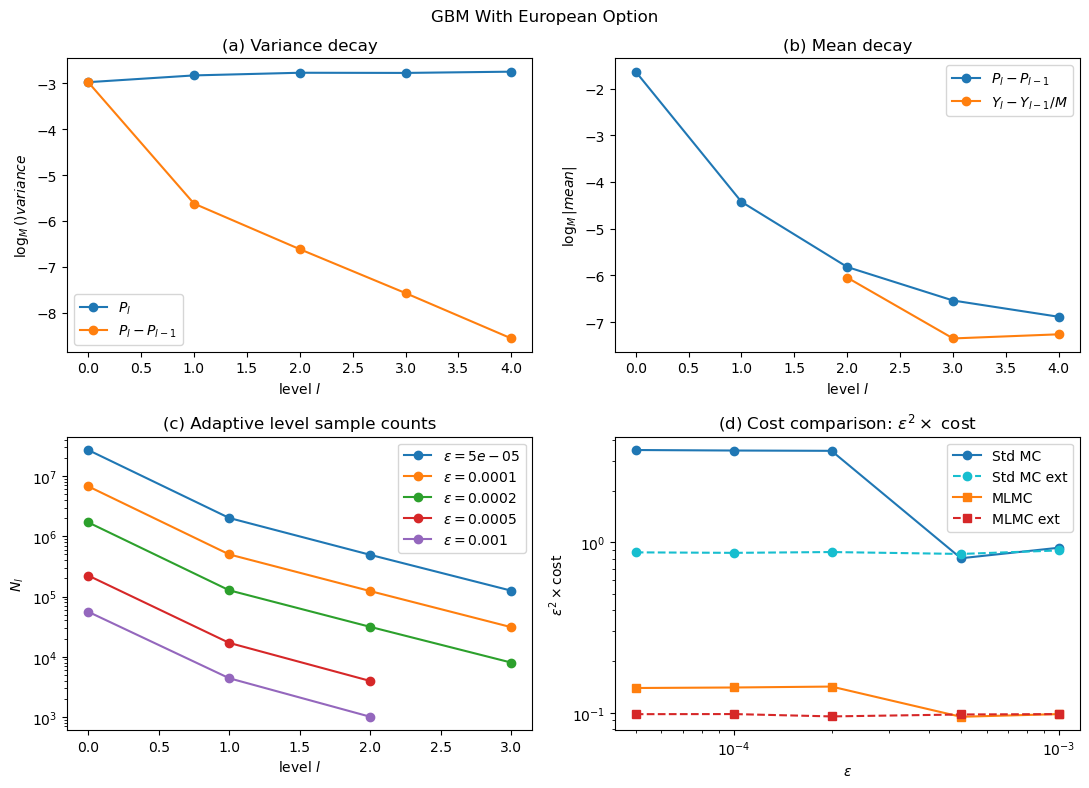

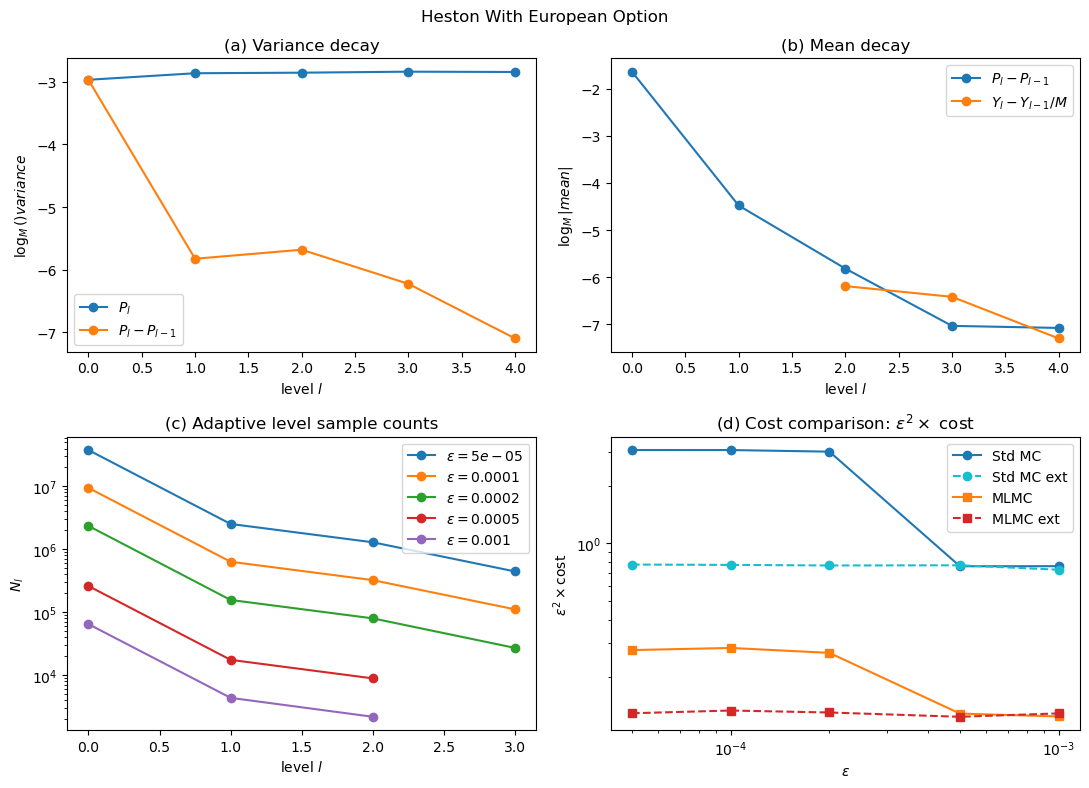

In [10]:
epsilons = [5e-5, 1e-4, 2e-4, 5e-4, 1e-3]

fig2 = panel_plot(gbm_problem(), epsilons, max_level=4, n_per_level=4000, seed=123, title='GBM With European Option')
fig2.show()
#fig2.savefig('GBM_European_Call.png', dpi=180, bbox_inches='tight')
#plt.close(fig2)

fig6 = panel_plot(heston_problem(), epsilons, max_level=4, n_per_level=4000, seed=123, title='Heston With European Option')
fig6.show()
#fig6.savefig('Heston_European_Call.png', dpi=180, bbox_inches='tight')
#plt.close(fig6)

## Section 4 - Extending MLMC for a basket of Asian options

This section defines the five asset correlated GBM basket experiment for Asian Options. 
We also simulate a Milstein path rather than the Euler discretisation and use Brownian interpolating in the Asian Payoff.  

##### a) Define model parameters and ser up basket and correlations


In [11]:
# Model parameters

Num_Stocks = 5
SIGMAS = np.array([0.2, 0.25, 0.3, 0.35, 0.4], dtype=float)
R = 0.05
T = 1.0
S0 = np.full(Num_Stocks, 100.0)
K = 100.0
RHO = 0.25
M = 2

CORR = np.full((Num_Stocks, Num_Stocks), RHO)
np.fill_diagonal(CORR, 1.0)
CHOLESKY = np.linalg.cholesky(CORR)

# Equal-weight basket
WEIGHTS = np.full(Num_Stocks, 1.0 / Num_Stocks)



# Generate Milstein paths

def correlated_gbm_paths(level: int, n: int, rng: np.random.Generator):
    """
    Milstein discretisation for correlated GBM asset paths.

    Returns
    -------
    paths : ndarray, shape (n, nsteps+1, Num_Stocks)
        Simulated asset paths.
    dW : ndarray, shape (n, nsteps, Num_Stocks)
        Correlated Brownian increments.
    """
    nsteps = M ** level
    h = T / nsteps

    z = rng.standard_normal((n, nsteps, Num_Stocks))
    dW = math.sqrt(h) * np.einsum('ij,nkj->nki', CHOLESKY, z)

    paths = np.empty((n, nsteps + 1, Num_Stocks), dtype=float)
    paths[:, 0, :] = S0

    sig = SIGMAS[None, :]

    for j in range(nsteps):
        Sj = paths[:, j, :]
        dWj = dW[:, j, :]

        paths[:, j + 1, :] = (
            Sj
            + R * Sj * h
            + sig * Sj * dWj
            + 0.5 * (sig ** 2) * Sj * (dWj ** 2 - h)
        )

    return paths, dW


def coarse_from_fine_dW(dW_f: np.ndarray):
    """
    Aggregate fine Brownian increments in blocks of size M=2
    to form the coupled coarse increments.
    """
    n, nf, d = dW_f.shape
    nc = nf // 2
    return dW_f.reshape(n, nc, 2, d).sum(axis=2)


def evolve_from_increments(dW: np.ndarray):
    """
    Rebuild the Milstein path from supplied Brownian increments.
    """
    n, nsteps, d = dW.shape
    h = T / nsteps

    paths = np.empty((n, nsteps + 1, d), dtype=float)
    paths[:, 0, :] = S0

    sig = SIGMAS[None, :]

    for j in range(nsteps):
        Sj = paths[:, j, :]
        dWj = dW[:, j, :]

        paths[:, j + 1, :] = (
            Sj
            + R * Sj * h
            + sig * Sj * dWj
            + 0.5 * (sig ** 2) * Sj * (dWj ** 2 - h)
        )

    return paths


def basket_average(paths: np.ndarray, weights: np.ndarray= WEIGHTS) -> np.ndarray:
    """
    Basket value at each time point.

    Returns shape (n, nsteps+1).
    """
    return np.tensordot(paths, weights, axes=([2], [0]))


def basket_path_vol(paths: np.ndarray, weights: np.ndarray= WEIGHTS) -> np.ndarray:
    """
    Effective basket diffusion coefficient b_n on each timestep,
    using the left endpoint of each interval.

    For asset j under GBM, the instantaneous diffusion loading is
        b_{j,n} = sigma_j * S_{j,n}.

    The basket coefficient satisfies
        b_n^2 = sum_{i,j} w_i b_{i,n} Corr_{ij} w_j b_{j,n}.
    """
    S_left = paths[:, :-1, :]  # shape (n, nsteps, Num_Stocks)

    expo = S_left * (weights[None, None, :] * SIGMAS[None, None, :])
    var = np.einsum('nti,ij,ntj->nt', expo, CORR, expo)

    return np.sqrt(np.maximum(var, 0.0))



#####  b) Define Asian payoff with Brownian Increments

In [12]:
def asian_payoff_conditional(paths: np.ndarray, weights: np.ndarray= WEIGHTS) -> np.ndarray:
    """
    Use Brownian interpolation - Condition on the basket endpoints on each interval, approximate
    the interval integral by a Gaussian with

        mu_n  = 0.5 * h * (x0 + x1)
        var_n = b_n^2 * h^3 / 12

    where b_n is the effective basket diffusion coefficient.

    Summing over intervals gives a Gaussian approximation for the total
    time integral, and hence for the arithmetic average. The payoff
    expectation is then computed via the Bachelier call formula.
    """
    basket = basket_average(paths, weights=weights)  # (n, nsteps+1)
    b = basket_path_vol(paths, weights=weights)      # (n, nsteps)

    nsteps = basket.shape[1] - 1
    h = T / nsteps
    disc = math.exp(-R * T)

    x0 = basket[:, :-1]
    x1 = basket[:, 1:]

    mu_integral = np.sum(0.5 * h * (x0 + x1), axis=1)
    var_integral = np.sum((b * b) * (h ** 3) / 12.0, axis=1)

    mu_avg = mu_integral / T
    var_avg = var_integral / (T * T)
    sig_avg = np.sqrt(np.maximum(var_avg, 0.0))

    out = np.empty_like(mu_avg)

    zero_mask = sig_avg < 1e-14
    out[zero_mask] = disc * np.maximum(mu_avg[zero_mask] - K, 0.0)

    nz = ~zero_mask
    d = (mu_avg[nz] - K) / sig_avg[nz]
    Phi = norm.cdf(d)
    phi = norm.pdf(d)

    out[nz] = disc * ((mu_avg[nz] - K) * Phi + sig_avg[nz] * phi)
    return out


##### c) Define the Milstein evolution 

In [13]:
def make_level_sampler(payoff_fn: Callable[[np.ndarray], np.ndarray]):
    """
    Uses Milstein evolution on both fine and coarse paths.
    """
    def level_sampler(level: int, n: int, rng: np.random.Generator):
        pf_paths, dWf = correlated_gbm_paths(level, n, rng)
        Pf = payoff_fn(pf_paths)

        if level == 0:
            y = Pf.copy()
            cost = float(M ** level)
        else:
            dWc = coarse_from_fine_dW(dWf)
            pc_paths = evolve_from_increments(dWc)
            Pc = payoff_fn(pc_paths)
            y = Pf - Pc
            cost = float(M ** level)

        #We don't use the Richardson Scheme here, Pext is defined to be Pf
        #This allows us to use mlmc_algorithm defined earlier. 
        Pext = Pf.copy()
        return y, Pf, Pext, cost

    return level_sampler


def make_problem(name: str, payoff_fn: Callable[[np.ndarray], np.ndarray]) -> MlmcProblem:
    return MlmcProblem(
        name=name,
        M=M,
        level_sampler=make_level_sampler(payoff_fn),
        initial_samples=5000,
    )


def estimate_level_curves(problem: MlmcProblem, max_level: int, n_per_level: int, seed: int = 123):
    rng = np.random.default_rng(seed)
    means, vars_, fine_vars = [], [], []

    for l in range(max_level + 1):
        y, pf, pext, _ = problem.level_sampler(l, n_per_level, rng)
        means.append(np.mean(y))
        vars_.append(np.var(y))
        fine_vars.append(np.var(pf))

    return np.array(means), np.array(vars_), np.array(fine_vars)

##### d) Generate results 
Create helper functions to produce a 4 panel plot of key results on bias and variance decay, cost per level, and optimal sample 

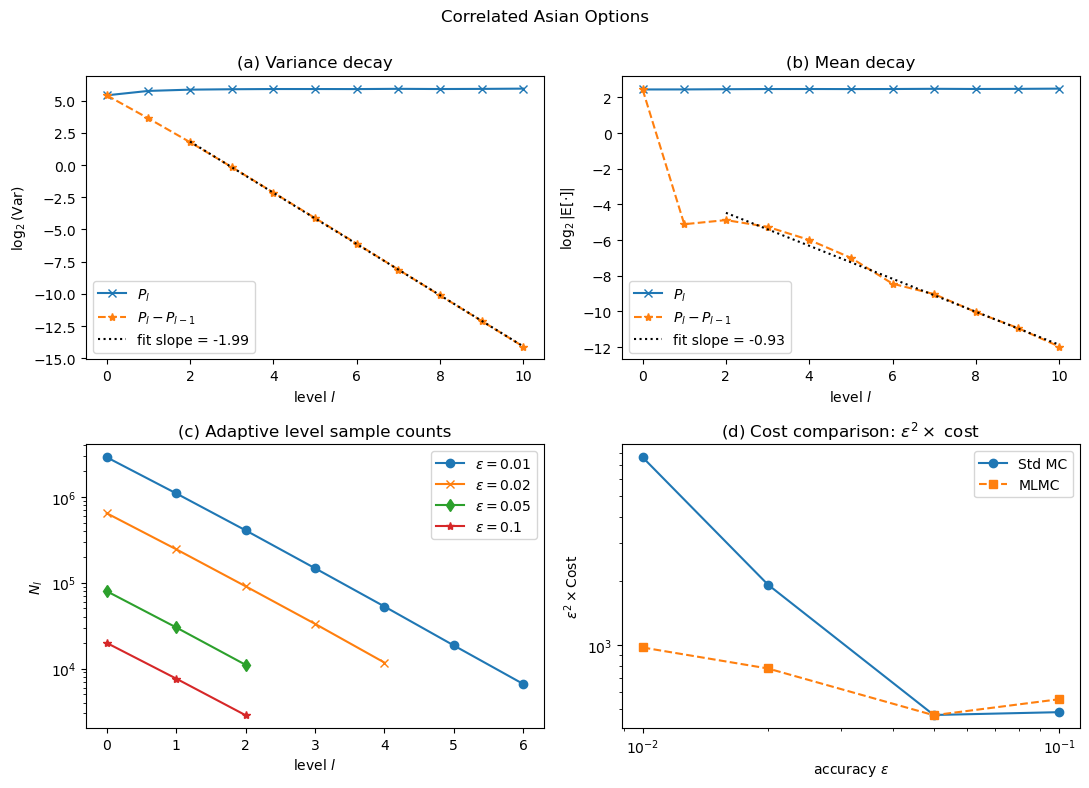

In [14]:

def safe_log2(x: np.ndarray, floor: float = 1e-30) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    return np.log2(np.maximum(np.abs(x), floor))


def fit_tail_slope(levels: np.ndarray, values: np.ndarray, tail_start: int = 2, floor: float = 1e-30):
    """
    Fit a straight line to log2(|values|) against level, using only the tail.
    Returns (slope, intercept). If not enough valid points, returns (nan, nan).
    """
    levels = np.asarray(levels, dtype=float)
    values = np.asarray(values, dtype=float)

    mask = np.abs(values) > floor
    mask &= levels >= tail_start

    if np.count_nonzero(mask) < 2:
        return np.nan, np.nan

    x = levels[mask]
    y = np.log2(np.maximum(np.abs(values[mask]), floor))
    slope, intercept = np.polyfit(x, y, 1)
    return float(slope), float(intercept)

def make_panel_plot(
    problem: MlmcProblem,
    eps_list: List[float],
    max_level: int,
    n_per_level: int,
    seed: int = 123,
    tail_start: int = 2,
    show_fit: bool = True,
):
    """
    Function that generates 4 panel plots; bias and variance decay, cost, and optimal sample size.

    Returns
    -------
    fig :  figure
    """
    eps_arr = np.array(sorted(eps_list), dtype=float)
    levels = np.arange(max_level + 1)

    corr_means = []
    corr_vars = []
    fine_means = []
    fine_vars = []

    # Use independent seeds per level for cleaner diagnostics
    for l in range(max_level + 1):
        rng_l = np.random.default_rng(seed + 1000 * l)
        y, pf, _, _ = problem.level_sampler(l, n_per_level, rng_l)

        corr_means.append(np.mean(y))
        corr_vars.append(np.var(y, ddof=1))
        fine_means.append(np.mean(pf))
        fine_vars.append(np.var(pf, ddof=1))

    corr_means = np.array(corr_means, dtype=float)
    corr_vars = np.array(corr_vars, dtype=float)
    fine_means = np.array(fine_means, dtype=float)
    fine_vars = np.array(fine_vars, dtype=float)

    # Tail slope fits
    var_slope, var_intercept = fit_tail_slope(levels, corr_vars, tail_start=tail_start)
    mean_slope, mean_intercept = fit_tail_slope(levels, corr_means, tail_start=tail_start)

    fig, ax = plt.subplots(2, 2, figsize=(11, 8))

    y_fv = safe_log2(fine_vars)
    y_cv = safe_log2(corr_vars)

    ax[0, 0].plot(levels, y_fv, 'x-', label=r'$P_l$')
    ax[0, 0].plot(levels, y_cv, '*--', label=r'$P_l-P_{l-1}$')

    if show_fit and np.isfinite(var_slope):
        xfit = levels[levels >= tail_start]
        yfit = var_intercept + var_slope * xfit
        ax[0, 0].plot(
            xfit, yfit, 'k:', lw=1.5,
            label=fr'fit slope = {var_slope:.2f}'
        )

    ax[0, 0].set_xlabel('level $l$')
    ax[0, 0].set_ylabel(r'$\log_2(\mathrm{Var})$')
    ax[0, 0].legend()

    y_fm = safe_log2(fine_means)
    y_cm = safe_log2(corr_means)

    ax[0, 1].plot(levels, y_fm, 'x-', label=r'$P_l$')
    ax[0, 1].plot(levels, y_cm, '*--', label=r'$P_l-P_{l-1}$')

    if show_fit and np.isfinite(mean_slope):
        xfit = levels[levels >= tail_start]
        yfit = mean_intercept + mean_slope * xfit
        ax[0, 1].plot(
            xfit, yfit, 'k:', lw=1.5,
            label=fr'fit slope = {mean_slope:.2f}'
        )

    ax[0, 1].set_xlabel('level $l$')
    ax[0, 1].set_ylabel(r'$\log_2 |\mathrm{E}[\cdot]|$')
    ax[0, 1].legend()

    markers = ['o', 'x', 'd', '*', 's', '^', 'v', '+']
    mc_costs = []
    mlmc_costs = []
    level_cap_hits = []

    for i, eps in enumerate(eps_arr):
        res = mlmc_algorithm(
            problem,
            float(eps),
            rng=np.random.default_rng(seed + 100000 + i),
            max_level=max_level,
        )

        lgrid = np.arange(res.L + 1)
        marker = markers[i % len(markers)]

        ax[1, 0].plot(
            lgrid,
            res.target_N[:res.L + 1],
            marker + '-',
            label=fr'$\varepsilon={eps:g}$'
        )

        mc_costs.append((eps ** 2) * res.standard_mc_cost)
        mlmc_costs.append((eps ** 2) * res.total_cost)

        hit_cap = (res.L >= max_level) and (not res.converged)
        level_cap_hits.append(hit_cap)

        if hit_cap:
            warnings.warn(
                f"{problem.name}: eps={eps:g} likely hit max_level={max_level} before convergence."
            )

    ax[1, 0].set_yscale('log')
    ax[1, 0].set_xlabel('level $l$')
    ax[1, 0].set_ylabel(r'$N_l$')
    ax[1, 0].legend()
    ax[0, 0].set_title('(a) Variance decay')
    ax[0, 1].set_title('(b) Mean decay')
    ax[1, 0].set_title('(c) Adaptive level sample counts')
    ax[1, 1].set_title(r'(d) Cost comparison: $\varepsilon^2 \times$ cost')


    mc_costs = np.array(mc_costs, dtype=float)
    mlmc_costs = np.array(mlmc_costs, dtype=float)

    ax[1, 1].plot(eps_arr, mc_costs, 'o-', label='Std MC')
    ax[1, 1].plot(eps_arr, mlmc_costs, 's--', label='MLMC')

    # Mark cap-hit points
    for eps, cost, hit in zip(eps_arr, mlmc_costs, level_cap_hits):
        if hit:
            ax[1, 1].annotate(
                'cap',
                xy=(eps, cost),
                xytext=(4, 4),
                textcoords='offset points',
                fontsize=8
            )

    ax[1, 1].set_xscale('log')
    ax[1, 1].set_yscale('log')
    ax[1, 1].set_xlabel(r'accuracy $\varepsilon$')
    ax[1, 1].set_ylabel(r'$\varepsilon^2 \times \mathrm{Cost}$')
    ax[1, 1].legend()

    title = (
        f"{problem.name}\n"
    )
    fig.suptitle(title)
    fig.tight_layout()

    return fig


eps = [0.1, 0.05, 0.02, 0.01]
problem = make_problem(
    'Correlated Asian Options',
    asian_payoff_conditional
)

fig = make_panel_plot(
    problem,
    eps_list=eps,
    max_level=10,
    n_per_level=50000,
    seed=123,
    tail_start=2,
)

plt.show()
#fig.savefig('Asian_Basket.png', dpi=180, bbox_inches='tight')


### Section 5 Adding MLQMC to the multilevel framework - Set-up
Add randomised rank-1 lattice + Brownian Bridge to the multilevel framework

##### a) Set-up SDEs and Payoffs
Set-up SDE discretisations for Euler-Maruyama and Milstein, and payoffs for Asian, Lookback, Digital, and Down and out barrier calls

In [15]:
#Set random seed 
np.random.seed(2026)

#IMAGES_DIR = "/Users/AnranSeverac/SimulationMethods/Figures"
#os.makedirs(IMAGES_DIR, exist_ok=True)

# GBM experiment setup
r_ex = 0.05
sigma_ex = 0.2
T_ex = 1.0
S0_ex = 1.0
K_ex = 1.0
B_ex = 0.8
M_ex = 4

# Target RMSE ε: geometric grid from 2e-2 down to 2e-3 (8 values). Shorter run: slice, e.g. eps_grid_ex[::2].
eps_grid_ex = np.geomspace(0.02, 0.002, num=8)

In [16]:
def euler_gbm_path_full_from_dW(S0, r, sigma, T, dW):
    n = len(dW)
    h = T / n
    S = np.zeros(n + 1)
    S[0] = S0
    for i in range(n):
        S[i + 1] = S[i] + r * S[i] * h + sigma * S[i] * dW[i]
    return S

def milstein_gbm_path_full_from_dW(S0, r, sigma, T, dW):
    n = len(dW)
    h = T / n
    S = np.zeros(n + 1)
    S[0] = S0
    for i in range(n):
        S[i + 1] = S[i] + r * S[i] * h + sigma * S[i] * dW[i] + 0.5 * sigma**2 * S[i] * (dW[i]**2 - h)
    return S

def gbm_path_full_from_dW(S0, r, sigma, T, dW, scheme='euler'):
    if scheme == 'milstein':
        return milstein_gbm_path_full_from_dW(S0, r, sigma, T, dW)
    return euler_gbm_path_full_from_dW(S0, r, sigma, T, dW)

def payoff_from_path(S_path, payoff_type, K=1.0, B=0.8, r=0.05, T=1.0):
    disc = np.exp(-r * T)
    ST = S_path[-1]
    if payoff_type == 'asian':
        return disc * max(np.mean(S_path) - K, 0.0)
    if payoff_type == 'lookback':
        return disc * max(ST - np.min(S_path), 0.0)
    if payoff_type == 'digital':
        return disc * (1.0 if ST > K else 0.0)
    if payoff_type == 'barrier':
        alive = np.min(S_path) > B
        return disc * max(ST - K, 0.0) * (1.0 if alive else 0.0)
    raise ValueError(f'Unknown payoff_type: {payoff_type}')

##### b) Construct randomized rank-1 lattice, Brownian bridge, and importance sampling

**Lattice construction.** Randomized rank-1 lattice:
$$u_i = \big\{\tfrac{i}{N}z + \Delta\big\},\quad i=0,\dots,N-1,$$
with generating vector $z\in\mathbb{Z}^d$ and random shift $\Delta\sim U([0,1)^d)$.

This maps to Gaussians and Brownian increments via a Brownian bridge, prioritising low-frequency path components in early dimensions.

**Importance sampling for digital payoffs (likelihood ratio method, MLQMC only).**
The digital payoff $\mathbf{1}_{\{S_T>K\}}$ is a hard discontinuity in QMC space, killing lattice gains. We apply a **change of measure** on the first Brownian bridge dimension (which controls $W(T)$, the primary driver of $S_T$).

Set the optimal IS shift so the tilted distribution centres $S_T$ on the strike:
$$\theta = \frac{\ln(K/S_0)-(r-\tfrac12\sigma^2)T}{\sigma\sqrt{T}}.$$

Replace $Z_1$ with $\tilde Z_1 = Z_1+\theta$ when building the terminal Brownian value $W(T)=\sqrt{T}\,\tilde Z_1$, then weight each payoff by the **Radon–Nikodym derivative**:
$$\mathcal{L} = \exp\!\bigl(-\theta Z_1 - \tfrac12\theta^2\bigr),$$
where $Z_1$ is the *original* (unshifted) standard normal. This keeps the estimator **unbiased** while **smoothing** the effective integrand: the QMC lattice no longer has to "find" a thin strip where the digital pays out; the measure shift places the grid right on the boundary, and $\mathcal{L}$ handles the reweighting.


In [17]:
def rank1_lattice_points(N, d, z, shift):
    i = np.arange(N, dtype=np.int64)[:, None]
    pts = (i * z[None, :]) / N + shift[None, :]
    return pts - np.floor(pts)

def brownian_bridge_schedule(n):
    schedule = []
    intervals = [(0, n)]
    while intervals:
        l, r = intervals.pop(0)
        if r - l <= 1:
            continue
        m = (l + r) // 2
        schedule.append((m, l, r))
        intervals.append((l, m))
        intervals.append((m, r))
    return schedule

def brownian_bridge_dW_from_u(u, T):
    d = len(u)
    t = np.linspace(0.0, T, d + 1)
    u = np.clip(u, 1e-12, 1.0 - 1e-12)
    z = norm.ppf(u)
    W = np.zeros(d + 1)
    W[d] = np.sqrt(T) * z[0]
    idx = 1
    for m, l, r in brownian_bridge_schedule(d):
        tl, tm, tr = t[l], t[m], t[r]
        mean = ((tr - tm) * W[l] + (tm - tl) * W[r]) / (tr - tl)
        var = (tm - tl) * (tr - tm) / (tr - tl)
        W[m] = mean + np.sqrt(max(var, 0.0)) * z[idx]
        idx += 1
        if idx >= len(z):
            break
    return np.diff(W)

def _interp_path_min(S_path, sigma, h, U):
    """Running minimum via Brownian interpolation (Giles & Waterhouse 2009, Eq. 6.1).
    U[i] ~ Uniform(0,1) is the random variable for timestep i."""
    path_min = S_path[0]
    for i in range(len(U)):
        b = sigma * S_path[i]
        arg = (S_path[i+1] - S_path[i])**2 - 2 * b**2 * h * np.log(max(U[i], 1e-300))
        s_min_i = 0.5 * (S_path[i] + S_path[i+1] - np.sqrt(max(arg, 0.0)))
        path_min = min(path_min, s_min_i)
    return path_min

def coupled_payoff_diff_from_dW(dW_fine, payoff_type, S0, r, sigma, T, K, B, M, scheme='euler'):
    S_f = gbm_path_full_from_dW(S0, r, sigma, T, dW_fine, scheme)
    n_f = len(dW_fine)
    h_f = T / n_f

    if payoff_type == 'lookback':
        disc = np.exp(-r * T)
        U = np.random.random(n_f)
        min_f = _interp_path_min(S_f, sigma, h_f, U)
        P_f = disc * max(S_f[-1] - min_f, 0.0)
        if n_f == 1:
            return P_f, P_f
        dW_c = dW_fine.reshape(-1, M).sum(axis=1)
        S_c = gbm_path_full_from_dW(S0, r, sigma, T, dW_c, scheme)
        n_c = len(dW_c)
        W = np.zeros(n_f + 1)
        W[1:] = np.cumsum(dW_fine)
        min_c = S_c[0]
        for j in range(n_c):
            b_c = sigma * S_c[j]
            S_sub = np.zeros(M + 1)
            S_sub[0], S_sub[M] = S_c[j], S_c[j + 1]
            W0, WM = W[j * M], W[(j + 1) * M]
            for k in range(1, M):
                lam = k / M
                S_sub[k] = S_c[j] + lam * (S_c[j+1] - S_c[j]) + b_c * (W[j*M + k] - W0 - lam * (WM - W0))
            for k in range(M):
                arg = (S_sub[k+1] - S_sub[k])**2 - 2 * b_c**2 * h_f * np.log(max(U[j*M + k], 1e-300))
                s_min_k = 0.5 * (S_sub[k] + S_sub[k+1] - np.sqrt(max(arg, 0.0)))
                min_c = min(min_c, s_min_k)
        P_c = disc * max(S_c[-1] - min_c, 0.0)
        return P_f - P_c, P_f

    P_f = payoff_from_path(S_f, payoff_type, K=K, B=B, r=r, T=T)
    if n_f == 1:
        return P_f, P_f
    dW_c = dW_fine.reshape(-1, M).sum(axis=1)
    S_c = gbm_path_full_from_dW(S0, r, sigma, T, dW_c, scheme)
    P_c = payoff_from_path(S_c, payoff_type, K=K, B=B, r=r, T=T)
    return P_f - P_c, P_f

# ── Importance-sampling helpers for digital payoff (likelihood ratio / change of measure) ──

def is_theta_digital(S0, r, sigma, T, K):
    """Optimal IS shift: centres the distribution of S_T on the strike K."""
    return (np.log(K / S0) - (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def brownian_bridge_dW_from_u_IS(u, T, theta):
    """Like brownian_bridge_dW_from_u, but shifts the first dimension by theta.
    Returns (dW, z1_original) where z1_original is the *unshifted* standard normal
    (needed for the likelihood ratio weight)."""
    d = len(u)
    t = np.linspace(0.0, T, d + 1)
    u = np.clip(u, 1e-12, 1.0 - 1e-12)
    z = norm.ppf(u)
    z1_original = z[0]
    z[0] = z[0] + theta
    W = np.zeros(d + 1)
    W[d] = np.sqrt(T) * z[0]
    idx = 1
    for m, l, r in brownian_bridge_schedule(d):
        tl, tm, tr = t[l], t[m], t[r]
        mean = ((tr - tm) * W[l] + (tm - tl) * W[r]) / (tr - tl)
        var = (tm - tl) * (tr - tm) / (tr - tl)
        W[m] = mean + np.sqrt(max(var, 0.0)) * z[idx]
        idx += 1
        if idx >= len(z):
            break
    return np.diff(W), z1_original

def coupled_payoff_diff_from_dW_IS(dW_fine, z1, theta, payoff_type, S0, r, sigma, T, K, B, M, scheme='euler'):
    """Coupled payoff with likelihood ratio weight for IS-shifted paths."""
    lr_weight = np.exp(-theta * z1 - 0.5 * theta**2)
    S_f = gbm_path_full_from_dW(S0, r, sigma, T, dW_fine, scheme)
    P_f = payoff_from_path(S_f, payoff_type, K=K, B=B, r=r, T=T) * lr_weight
    if len(dW_fine) == 1:
        return P_f, P_f
    dW_c = dW_fine.reshape(-1, M).sum(axis=1)
    S_c = gbm_path_full_from_dW(S0, r, sigma, T, dW_c, scheme)
    P_c = payoff_from_path(S_c, payoff_type, K=K, B=B, r=r, T=T) * lr_weight
    return P_f - P_c, P_f

##### c) Level Estimators abd adaptive schemes
For each level:
$$Y_l = \mathbb{E}[\hat P_l-\hat P_{l-1}],\; l\ge1,\qquad Y_0=\mathbb{E}[\hat P_0].$$

- MLMC: i.i.d. coupled paths.
- MLQMC: average over lattice points for each random shift, then average shifts.

We compare complexity via normalized cost $\varepsilon^2\times\text{cost}$.

**Note:** For **discontinuous** payoffs (digital), estimated level variances are noisy and the adaptive loop may require many outer passes before the variance target is met.

In [18]:
def mlmc_level_estimate(level, N, payoff_type, S0, r, sigma, T, K, B, M, scheme='euler'):
    """MLMC level estimator (standard MC, no IS)."""
    diffs = np.zeros(N)
    fine = np.zeros(N)
    n_fine = M ** level
    h = T / n_fine
    for i in range(N):
        dW = np.sqrt(h) * np.random.standard_normal(n_fine)
        val, pf = coupled_payoff_diff_from_dW(dW, payoff_type, S0, r, sigma, T, K, B, M, scheme=scheme)
        diffs[i] = val
        fine[i] = pf
    if level == 0:
        return np.mean(fine), np.var(fine, ddof=1) / N, np.var(fine, ddof=1), N
    return np.mean(diffs), np.var(diffs, ddof=1) / N, np.var(diffs, ddof=1), N * (M**level + M**(level-1))

def mlqmc_level_estimate(level, N_lattice, q_shifts, payoff_type, S0, r, sigma, T, K, B, M, scheme='euler'):
    """MLQMC level estimator. For digital payoffs at level 0, uses IS-shifted Brownian bridge
    to smooth the base payoff. At levels >= 1, IS is *not* applied: the measure shift centres mass
    on the strike boundary, which *increases* the rate of fine/coarse disagreements and can
    raise the variance of P_f - P_c."""
    use_is = (payoff_type == 'digital') and (level == 0)
    theta = is_theta_digital(S0, r, sigma, T, K) if use_is else 0.0
    d = M ** level
    z_gen = 2 * np.arange(1, d + 1, dtype=np.int64) - 1
    y_shift = np.zeros(q_shifts)
    for j in range(q_shifts):
        shift = np.random.random(d)
        U = rank1_lattice_points(N_lattice, d, z_gen, shift)
        vals = np.zeros(N_lattice)
        for i in range(N_lattice):
            if use_is:
                dW_f, z1 = brownian_bridge_dW_from_u_IS(U[i], T, theta)
                val, pf = coupled_payoff_diff_from_dW_IS(dW_f, z1, theta, payoff_type, S0, r, sigma, T, K, B, M, scheme=scheme)
            else:
                dW_f = brownian_bridge_dW_from_u(U[i], T)
                val, pf = coupled_payoff_diff_from_dW(dW_f, payoff_type, S0, r, sigma, T, K, B, M, scheme=scheme)
            vals[i] = pf if level == 0 else val
        y_shift[j] = np.mean(vals)
    Yhat = np.mean(y_shift)
    Vhat = np.var(y_shift, ddof=1) / q_shifts if q_shifts > 1 else 0.0
    Vshift = np.var(y_shift, ddof=1) if q_shifts > 1 else 0.0
    cost = q_shifts * N_lattice * (1 if level == 0 else (M**level + M**(level-1)))
    return Yhat, Vhat, Vshift, cost

def run_experiment_mlmc(
    payoff_type,
    eps,
    S0=S0_ex,
    r=r_ex,
    sigma=sigma_ex,
    T=T_ex,
    K=K_ex,
    B=B_ex,
    M=M_ex,
    N_pilot=1200,
    L_max=None,
    verbose=False,
    scheme='euler',
):
    """Adaptive MLMC with selectable discretisation (euler or milstein).
    If L_max is None, levels increase until the variance and bias criteria are met."""
    L = 0
    Y, Vsingle, N = {}, {}, {}
    var_target = eps**2 / 2
    pass_idx = 0
    tiny = np.finfo(float).tiny
    while True:
        pass_idx += 1
        if L not in Y:
            y, _, vs, _ = mlmc_level_estimate(L, N_pilot, payoff_type, S0, r, sigma, T, K, B, M, scheme=scheme)
            Y[L], Vsingle[L] = y, max(vs, 1e-14)
        sum_sqrt = max(
            sum(np.sqrt(max(Vsingle[l], tiny) * (T / M**l)) for l in range(L + 1)),
            tiny,
        )
        for l in range(L + 1):
            hl = T / (M ** l)
            va = max(Vsingle[l], tiny)
            raw = int(np.ceil(2 * (eps**-2) * np.sqrt(va * hl) / sum_sqrt))
            N[l] = max(raw, 1)
        total_var, total_cost = 0.0, 0
        for l in range(L + 1):
            y, ve, vs, c = mlmc_level_estimate(l, N[l], payoff_type, S0, r, sigma, T, K, B, M, scheme=scheme)
            Y[l], Vsingle[l] = y, max(vs, 1e-14)
            total_var += ve
            total_cost += c
        bias_proxy = abs(Y[L]) if L == 0 else max(abs(Y[L]), abs(Y[L-1]) / M)
        if verbose:
            print(
                f"  MLMC pass {pass_idx}: L={L}, total_var={total_var:.3e} (target {var_target:.3e}), "
                f"bias_proxy={bias_proxy:.3e}, max_N_level={max(N.values())}"
            )
        if total_var <= var_target and (
            (L >= 2 and bias_proxy <= eps / np.sqrt(2)) or (L_max is not None and L >= L_max)
        ):
            break
        if L_max is not None and L >= L_max:
            break
        L += 1
    return {
        'estimate': sum(Y[l] for l in range(L + 1)),
        'cost': total_cost,
        'L': L,
        'bias_proxy': bias_proxy,
        'mlmc_passes': pass_idx,
        'variance_ok': total_var <= var_target,
        'total_var': total_var,
        'scheme': scheme,
    }

def run_experiment_mlqmc(payoff_type, eps, S0=S0_ex, r=r_ex, sigma=sigma_ex, T=T_ex, K=K_ex, B=B_ex, M=M_ex, q_shifts=12, N0=8, L_max=None, scheme='euler'):
    """Adaptive MLQMC with selectable discretisation (euler or milstein).
    If L_max is None, the level count is limited only by the bias stopping criterion."""
    L = 0
    Y, Vest, Nlat = {}, {}, {}
    while True:
        for l in range(L + 1):
            Nlat.setdefault(l, N0)
            y, ve, _, _ = mlqmc_level_estimate(l, Nlat[l], q_shifts, payoff_type, S0, r, sigma, T, K, B, M, scheme=scheme)
            Y[l], Vest[l] = y, max(ve, 1e-16)
        while sum(Vest[l] for l in range(L + 1)) > eps**2 / 2:
            l_star = max(range(L + 1), key=lambda l: Vest[l] / ((M**l) * Nlat[l] + 1e-16))
            Nlat[l_star] *= 2
            y, ve, _, _ = mlqmc_level_estimate(l_star, Nlat[l_star], q_shifts, payoff_type, S0, r, sigma, T, K, B, M, scheme=scheme)
            Y[l_star], Vest[l_star] = y, max(ve, 1e-16)
        bias_proxy = abs(Y[L]) if L == 0 else max(abs(Y[L]), abs(Y[L-1]) / M)
        if L >= 2 and bias_proxy <= eps / np.sqrt(2):
            break
        if L_max is not None and L >= L_max:
            break
        L += 1
    total_cost = sum(
        q_shifts * Nlat[l] * (1 if l == 0 else (M**l + M**(l-1)))
        for l in range(L + 1)
    )
    return {'estimate': sum(Y[l] for l in range(L + 1)), 'cost': total_cost, 'L': L, 'bias_proxy': bias_proxy, 'scheme': scheme}

### Section 6 Adding MLQMC to the multilevel framework - Results

We compare **MLMC** and **MLQMC** on `{'asian','lookback','digital','barrier'}`, using the **Milstein** scheme throughout.  The Milstein correction $\frac12\sigma^2 S(\Delta W^2-h)$ raises the strong order from $\frac12$ (Euler) to 1, accelerating the decay of level-difference variance from $V_l=O(h_l)$ to $V_l=O(h_l^2)$ for Lipschitz payoffs and improving MLMC cost from $O(\varepsilon^{-2}(\log\varepsilon)^2)$ to $O(\varepsilon^{-2})$.  For GBM the Itô–Taylor correction has a closed form, so the extra cost per timestep is negligible.

across a **geometric** grid of target accuracies `eps_grid_ex`.

The figure plots $\varepsilon^2\times\text{cost}$ on a log-log scale, with fitted empirical slopes and theoretical reference lines ($O(\varepsilon^{-2})$ flat for MLMC, slope $+1$ for MLQMC at $O(\varepsilon^{-1})$).

In [19]:
payoffs_ex = ['asian', 'lookback', 'digital', 'barrier']

def scheme_for(payoff):
    return 'milstein'

methods = [
    ('MLMC',  lambda p, e: run_experiment_mlmc(p, e, scheme=scheme_for(p)),  'o-',  'C0'),
    ('MLQMC', lambda p, e: run_experiment_mlqmc(p, e, scheme=scheme_for(p)), 's-',  'C2'),
]
results_ex = {p: {m[0]: [] for m in methods} for p in payoffs_ex}

for p in payoffs_ex:
    print(f'--- Payoff: {p} (scheme={scheme_for(p)}) ---')
    for eps in eps_grid_ex:
        parts = []
        for mname, mfn, _, _ in methods:
            out = mfn(p, eps)
            results_ex[p][mname].append((eps, out))
            e2c = eps**2 * out['cost']
            extra = ''
            if 'mlmc_passes' in out:
                extra = f", passes={out['mlmc_passes']}, var_ok={out['variance_ok']}"
            parts.append(f"{mname}: est={out['estimate']:.6f}, L={out['L']}, e2c={e2c:.3f}{extra}")
        print(f"  eps={eps:.4g} | " + " | ".join(parts))

# ── Annotated complexity figure ──
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

TITLE_MAP = {'asian': 'Asian', 'lookback': 'Lookback', 'digital': 'Digital', 'barrier': 'Barrier'}

shared_xticks = [0.002, 0.003, 0.005, 0.007, 0.01, 0.02]
shared_xticklabels = ['0.002', '0.003', '0.005', '0.007', '0.01', '0.02']

fig, axs = plt.subplots(2, 2, figsize=(12, 9))
axs = axs.ravel()

for ax, p in zip(axs, payoffs_ex):
    eps_arr = np.array([x[0] for x in results_ex[p]['MLMC']])

    for mname, _, style, color in methods:
        cost_arr = np.array([x[1]['cost'] for x in results_ex[p][mname]], dtype=float)
        y = np.maximum(eps_arr**2 * cost_arr, np.finfo(float).tiny)
        ax.loglog(eps_arr, y, style, color=color, markersize=7, linewidth=2.0)

    e_ref = np.array([eps_arr.min() * 0.85, eps_arr.max() * 1.15])

    mlmc_e2c = eps_arr**2 * np.array([x[1]['cost'] for x in results_ex[p]['MLMC']], dtype=float)
    anchor_flat = np.exp(np.mean(np.log(np.maximum(mlmc_e2c, 1e-20))))
    ax.loglog(e_ref, [anchor_flat, anchor_flat], '--', color='#aaaaaa', linewidth=1.3, zorder=1)

    qmc_e2c = eps_arr**2 * np.array([x[1]['cost'] for x in results_ex[p]['MLQMC']], dtype=float)
    log_mid = np.mean(np.log10(eps_arr))
    anchor_slope = np.exp(np.mean(np.log(np.maximum(qmc_e2c, 1e-20))))
    ref_y = anchor_slope * (e_ref / 10**log_mid)
    ax.loglog(e_ref, ref_y, '--', color='#aaaaaa', linewidth=1.3, zorder=1)

    ax.set_title(TITLE_MAP[p], fontsize=14, fontweight='bold', pad=8)
    ax.grid(True, which='major', alpha=0.3, linewidth=0.6)
    ax.grid(True, which='minor', alpha=0.12, linewidth=0.4)

    ax.set_xticks(shared_xticks)
    ax.set_xticklabels(shared_xticklabels)
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_xlim(0.0015, 0.028)
    ax.set_ylim(5e-3, 50)
    ax.tick_params(axis='both', which='major', labelsize=9.5, width=1.0, length=5)
    ax.tick_params(axis='both', which='minor', width=0.6, length=3)

    ax.set_xlabel(r'$\varepsilon$', fontsize=12)
    if p in ('asian', 'digital'):
        ax.set_ylabel(r'$\varepsilon^2 \times \mathrm{cost}$', fontsize=12)

legend_handles = [
    Line2D([0], [0], color='C0', marker='o', linewidth=2.0, markersize=7, label='MLMC'),
    Line2D([0], [0], color='C2', marker='s', linewidth=2.0, markersize=7, label='MLQMC'),
    Line2D([0], [0], color='#aaaaaa', linewidth=1.3, linestyle='--', label=r'$O(\varepsilon^{-2})$ reference (flat)'),
    Line2D([0], [0], color='#aaaaaa', linewidth=1.3, linestyle='--',
           marker=r'$\nearrow$', markersize=8, label=r'$O(\varepsilon^{-1})$ reference (slope 1)'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=10,
           frameon=True, framealpha=0.95, edgecolor='#cccccc',
           bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.045, 1, 1], h_pad=2.5, w_pad=2.0)
#exotic_cost_path = os.path.join(IMAGES_DIR, 'exotic_mlmc_mlqmc_comparison.png')
fig.savefig("Exotic_Options.png", dpi=300, bbox_inches='tight')
print(f"Saved: {exotic_cost_path}")
plt.show()

--- Payoff: asian (scheme=milstein) ---
  eps=0.02 | MLMC: est=0.056529, L=2, e2c=4.727, passes=3, var_ok=True | MLQMC: est=0.058762, L=2, e2c=0.998
  eps=0.01439 | MLMC: est=0.057434, L=2, e2c=4.725, passes=3, var_ok=True | MLQMC: est=0.064509, L=2, e2c=0.517
  eps=0.01036 | MLMC: est=0.057080, L=2, e2c=4.789, passes=3, var_ok=True | MLQMC: est=0.051826, L=2, e2c=0.268
  eps=0.007455 | MLMC: est=0.055878, L=2, e2c=4.688, passes=3, var_ok=True | MLQMC: est=0.058931, L=2, e2c=0.139
  eps=0.005365 | MLMC: est=0.055951, L=2, e2c=4.765, passes=3, var_ok=True | MLQMC: est=0.053251, L=2, e2c=0.075
  eps=0.003861 | MLMC: est=0.056646, L=2, e2c=4.778, passes=3, var_ok=True | MLQMC: est=0.058998, L=2, e2c=0.049
  eps=0.002779 | MLMC: est=0.057262, L=3, e2c=5.533, passes=4, var_ok=True | MLQMC: est=0.055251, L=2, e2c=0.033


KeyboardInterrupt: 